<a href="https://colab.research.google.com/github/navap3206-debug/hello-world/blob/main/A04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import matplotlib.pyplot as plt
import numpy as np

DATOS DE INICIO Y LOS QUE ENCONTRAMOS

In [172]:
y_data = [2847,-4017,-1255,1773,563,2847.31363,2849.5981,2852.69711]
X_data = [10,2,3,7,12,9.9963,9.9651, 9.8741]

y = np.array(y_data).reshape(-1, 1)
X = np.array(X_data).reshape(-1, 1)





ENTRENAMOS EL MODELO CON LA MATRIZ

In [173]:
gpr = GaussianProcessRegressor(n_restarts_optimizer=10,random_state=42)
gpr.fit(X,y)


GaussianProcessRegressor(n_restarts_optimizer=10, random_state=42)

CREAMOS UN VECTOR ENTRE [2-15] Y PREDECIMOS LOS 1000 PUNTOS EN MEDIO

In [178]:
x_pred = np.linspace(2, 15, 1001).reshape(-1, 1)
y_pred, sigma = gpr.predict(x_pred, return_std=True)
y_pred


array([-4016.99999948, -4001.83509857, -3985.80507886, ...,
          -4.63795451,    -4.46392311,    -4.2956492 ])

BUSCAMOS EL LUGAR DEL Y PREDICHA MÁS ALTO Y BUSCAMOS QUE X DEBERÍAMOS CONSULTAR

In [179]:
indice_max_ = np.argmax(y_pred) #dOnde esta sigma más alto
nuevo_x = x_pred[indice_max_].reshape(1, 1) #¿QUE X ES?
nuevo_y = y_pred[indice_max_]
print(nuevo_y)
nuevo_x


2852.7283325712197


array([[9.865]])

GRAFICAMOS Y ESTABLECEMOS NUESTRO INTERVALO DE CONFIANZA

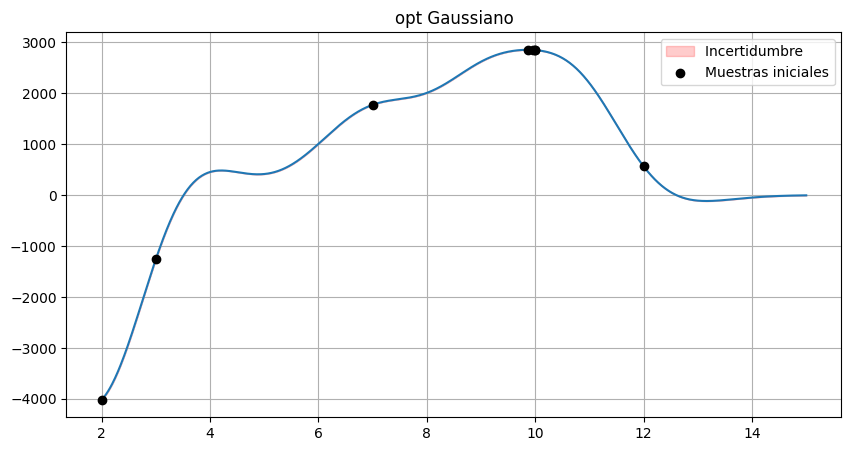

In [181]:
# Graficamos nuestra primera propuesta
plt.figure(figsize=(10, 5))

plt.plot(x_pred, y_pred)

# Dibujamos los intervalos de confianza
plt.fill_between(x_pred.ravel(),
                 y_pred - 1.96 * sigma,
                 y_pred + 1.96 * sigma,
                 alpha=0.2, color='red', label='Incertidumbre ')

plt.scatter(X, y, c='black', zorder=10, label='Muestras iniciales')
plt.title("opt Gaussiano")
plt.legend()
plt.grid()
plt.show()